### jupyter version of VAE_mouse_kFoldOn_mouseAtlas.py
### for figure2 A&B


In [1]:
# -*-coding:utf-8 -*-
import os
import torch

torch.set_float32_matmul_precision('high')
import pyro
import logging
from utils.logging_system import LogHelper

smoke_test = ('CI' in os.environ)  # ignore; used to check code integrity in the Pyro repo
assert pyro.__version__.startswith('1.8.5')
pyro.set_rng_seed(1)
from utils.utils_DandanProject import str2bool, auto_select_gpu_and_cpu, preprocessData_and_dropout_some_donor_or_gene
from utils.utils_DandanProject import task_kFoldTest, onlyTrain_model, identify_timeCorGene
from collections import Counter

import yaml
import argparse
from utils.utils_Dandan_plot import Embryodonor_resort_key
import numpy as np
import os

if os.getcwd().split("/")[-1] != "TemporalVAE":
    os.chdir("..")

### Parameters for code

In [2]:
parser = argparse.ArgumentParser(description="CNN model for prediction of gene paris' regulatory relationship")
parser.add_argument('--result_save_path', type=str,  # 2023-07-13 17:40:22
                    default="results/Fig2_kFoldOn_mouseAtlas/",
                    help="results all save here")
parser.add_argument('--file_path', type=str,
                    default="/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/",
                    help="sc file folder path.")
# ------------------ preprocess sc data setting ------------------
parser.add_argument('--min_gene_num', type=int,
                    default="100",
                    help="filter cell with min gene num, default 50")
parser.add_argument('--min_cell_num', type=int,
                    default="50",
                    help="filter gene with min cell num, default 50")
# ------------------ model training setting ------------------
parser.add_argument('--train_epoch_num', type=int,
                    default="100",
                    help="Train epoch num")
parser.add_argument('--batch_size', type=int,
                    default=100000,
                    help="batch size")
parser.add_argument('--time_standard_type', type=str,
                    default="embryoneg5to5",
                    help="y_time_nor_train standard type may cause different latent space: log2, 0to1, neg1to1, labeldic,sigmoid,logit")
parser.add_argument('--vae_param_file', type=str,
                    default="supervise_vae_regressionclfdecoder_mouse_stereo",
                    help="vae model parameters file.")
# ------------------ task setting ------------------
parser.add_argument('--kfold_test', action="store_true",
                    help="(Optional) make the task k fold test on dataset.", default=True)
parser.add_argument('--train_whole_model', action="store_true",
                    help="(Optional) use all data to train a model.", default=True)
parser.add_argument('--identify_time_cor_gene', action="store_true",
                    help="(Optional) identify time-cor gene by model trained by all.", default=False)
parser.add_argument('--use_checkpoint_bool', type=str2bool,
                    default="False",
                    help="use checkpoint file as pre-trained model or not.")
args = parser.parse_args("")

### set logger and vae model parameters from yaml file

In [3]:
data_golbal_path = "data/"
result_save_path = "results/" + args.result_save_path + "/"
data_path = args.file_path + "/"
yaml_path = "vae_model_configs/"
if args.use_checkpoint_bool:
    checkpoint_file = 'checkpoint_files/mouse_atlas.ckpt'
else:
    checkpoint_file = None
# --------------------------------------- import vae model parameters from yaml file----------------------------------------------
with open(yaml_path + "/" + args.vae_param_file + ".yaml", 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)
# --------------------------set logger and parameters, creat result save path and folder----------------------------------
latent_dim = config['model_params']['latent_dim']

time_standard_type = args.time_standard_type
sc_data_file_csv = data_path + "/data_count_hvg.csv"
cell_info_file_csv = data_path + "/cell_with_time.csv"

_path = '{}/{}/'.format(result_save_path, data_path)
if not os.path.exists(_path):
    os.makedirs(_path)

logger_file = '{}/{}_dim{}_time{}_epoch{}_minGeneNum{}.log'.format(_path, args.vae_param_file, latent_dim,
                                                                   time_standard_type, args.train_epoch_num,
                                                                   args.min_gene_num)
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
_logger.info("Finished setting up the logger at: {}.".format(logger_file))
_logger.info("Train on dataset: {}.".format(data_golbal_path + data_path))
device = auto_select_gpu_and_cpu()
_logger.info("Auto select run on {}".format(device))
_logger.info("load vae model parameters from file: {}".format(yaml_path + args.vae_param_file + ".yaml"))

2024-05-09 06:57:55,973 INFO - __main__ - Finished setting up the logger at: results/results/Fig2_kFoldOn_mouseAtlas////mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000////supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch100_minGeneNum100.log. 
2024-05-09 06:57:55,144 INFO - __main__ - Train on dataset: data//mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000//. 
2024-05-09 06:57:55,227 INFO - __main__ - Auto select run on cuda:2 
2024-05-09 06:57:55,228 INFO - __main__ - load vae model parameters from file: vae_model_configs/supervise_vae_regressionclfdecoder_mouse_stereo.yaml 


[INFO] GPU device 2 - total: 40.0GB; - memory free: 39.373GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.257GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 39.373GB


In [4]:
# ------------ Preprocess data, with hvg gene from preprocess_data_mouse_embryonic_development.py------------------------
sc_expression_df, cell_time = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path, sc_data_file_csv, cell_info_file_csv,
                                                                            min_cell_num=args.min_cell_num,
                                                                            min_gene_num=args.min_gene_num)

special_path_str = ""

2024-05-09 06:57:55,232 INFO - utils.utils_DandanProject - the original sc expression anndata should be gene as row, cell as column 
2024-05-09 06:59:59,947 INFO - utils.utils_DandanProject - read the original sc expression anndata with shape (gene, cell): (979, 881168) 
2024-05-09 06:59:59,959 INFO - utils.utils_DandanProject - Import data, cell number: 881168, gene number: 979 
2024-05-09 07:00:12,009 INFO - utils.utils_DandanProject - After drop gene threshold: 50, cell threshold: 100, remain adata shape: (881168, 979) 
2024-05-09 07:00:12,010 INFO - utils.utils_DandanProject - Drop cells with less than 100 gene expression, drop genes which none expression in 50 samples 
2024-05-09 07:00:12,011 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-09 07:00:19,253 INFO - utils.utils_DandanProject - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 
2024-05-09 07:00:36,662 INFO - utils

### set donor list and dictionary

In [5]:
# ---------------------------------------- set donor list and dictionary -----------------------------------------------------
donor_list = np.unique(cell_time["donor"])
donor_list = sorted(donor_list, key=Embryodonor_resort_key)
donor_dic = dict()
for i in range(len(donor_list)):
    donor_dic[donor_list[i]] = i
batch_dic = donor_dic.copy()
_logger.info("Consider donor as batch effect, donor use label: {}".format(donor_dic))
_logger.info("For each donor (donor_id, cell_num):{} ".format(Counter(cell_time["donor"])))

2024-05-09 07:00:41,406 INFO - __main__ - Consider donor as batch effect, donor use label: {'embryo_1': 0, 'embryo_2': 1, 'embryo_3': 2, 'embryo_4': 3, 'embryo_5': 4, 'embryo_6': 5, 'embryo_7': 6, 'embryo_8': 7, 'embryo_9': 8, 'embryo_10': 9, 'embryo_11': 10, 'embryo_12': 11, 'embryo_13': 12, 'embryo_14': 13, 'embryo_15': 14, 'embryo_16': 15, 'embryo_17': 16, 'embryo_18': 17, 'embryo_19': 18, 'embryo_20': 19, 'embryo_21': 20, 'embryo_22': 21, 'embryo_23': 22, 'embryo_24': 23, 'embryo_25': 24, 'embryo_26': 25, 'embryo_27': 26, 'embryo_28': 27, 'embryo_29': 28, 'embryo_30': 29, 'embryo_31': 30, 'embryo_32': 31, 'embryo_33': 32, 'embryo_34': 33, 'embryo_35': 34, 'embryo_36': 35, 'embryo_37': 36, 'embryo_38': 37, 'embryo_39': 38, 'embryo_40': 39, 'embryo_41': 40, 'embryo_42': 41, 'embryo_43': 42, 'embryo_44': 43, 'embryo_45': 44, 'embryo_46': 45, 'embryo_47': 46, 'embryo_48': 47, 'embryo_49': 48, 'embryo_50': 49, 'embryo_51': 50, 'embryo_52': 51, 'embryo_53': 52, 'embryo_54': 53, 'embryo_5

### K-FOLD TEST

2024-05-09 07:00:41,512 INFO - __main__ - start task: k-fold test with ['embryo_1', 'embryo_2', 'embryo_3', 'embryo_4', 'embryo_5', 'embryo_6', 'embryo_7', 'embryo_8', 'embryo_9', 'embryo_10', 'embryo_11', 'embryo_12', 'embryo_13', 'embryo_14', 'embryo_15', 'embryo_16', 'embryo_17', 'embryo_18', 'embryo_19', 'embryo_20', 'embryo_21', 'embryo_22', 'embryo_23', 'embryo_24', 'embryo_25', 'embryo_26', 'embryo_27', 'embryo_28', 'embryo_29', 'embryo_30', 'embryo_31', 'embryo_32', 'embryo_33', 'embryo_34', 'embryo_35', 'embryo_36', 'embryo_37', 'embryo_38', 'embryo_39', 'embryo_40', 'embryo_41', 'embryo_42', 'embryo_43', 'embryo_44', 'embryo_45', 'embryo_46', 'embryo_47', 'embryo_48', 'embryo_49', 'embryo_50', 'embryo_51', 'embryo_52', 'embryo_53', 'embryo_54', 'embryo_55', 'embryo_56', 'embryo_57', 'embryo_58', 'embryo_59', 'embryo_60', 'embryo_61', 'embryo_62', 'embryo_63', 'embryo_64', 'embryo_65', 'embryo_66', 'embryo_67', 'embryo_68', 'embryo_69', 'embryo_70', 'embryo_71', 'embryo_72']. 

Free Memory Percentage: 55.25%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 39.373GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.257GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 2,- memory free: 39.373GB


2024-05-09 07:01:49,648 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2024-05-09 07:01:49,648 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2024-05-09 07:01:49,649 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2024-05-09 07:01:49,649 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 


======= Training SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial =======


2024-05-09 07:01:50,342 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2024-05-09 07:01:50,346 INFO - pytorch_lightning.callbacks.model_summary - 
  | Name  | Type                                                         | Params
---------------------------------------------------------------------------------------
0 | model | SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial | 3.5 M 
---------------------------------------------------------------------------------------
3.5 M     Trainable params
0         Non-trainable params
3.5 M     Total params
13.967    Total estimated model params size (MB) 
2024-05-09 20:01:50.863406: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-09 20:01:51.81057

...

2024-05-09 07:16:41,077 INFO - utils.utils_DandanProject - this epoch final, on test data:[{'test_loss_epoch': 3.1989905834198, 'test_Reconstruction_loss_epoch': 1.4307518005371094, 'test_KLD_epoch': -3457.1083984375, 'test_clf_loss_epoch': 0.9039615392684937}] 
2024-05-09 07:16:41,093 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:432: PossibleUserWarning: The dataloader, predict_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 128 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Predicting: 0it [00:00, ?it/s]

2024-05-09 07:16:50,520 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 


Predicting: 0it [00:00, ?it/s]

2024-05-09 07:16:50,579 INFO - utils.utils_DandanProject - The Array does not contain NaN values 
2024-05-09 07:16:50,580 INFO - utils.utils_DandanProject - predicted time of test donor is continuous. 
2024-05-09 07:16:50,581 INFO - utils.utils_DandanProject - Plot training loss line for check. 
2024-05-09 07:16:50,684 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/results/Fig2_kFoldOn_mouseAtlas/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch100_minGeneNum100/embryo_1/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1715256113.GPU2.3527892.0 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/results/Fig2_kFoldOn_mouseAtlas/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regress

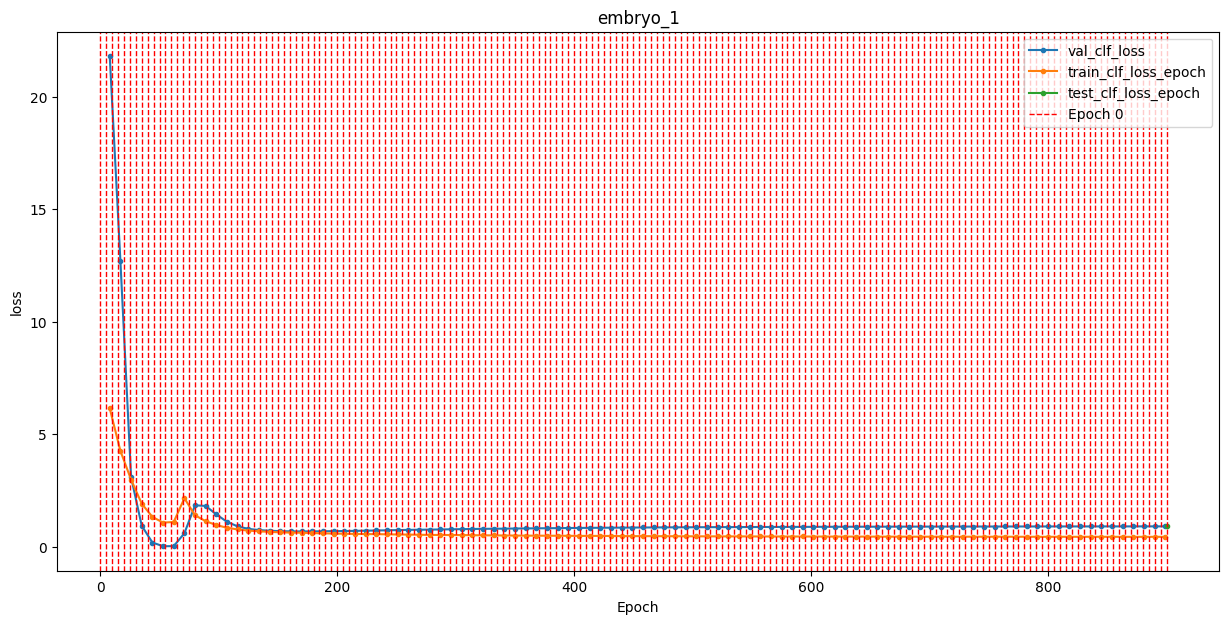

2024-05-09 07:16:51,996 INFO - utils.utils_Dandan_plot - plot training process. 
2024-05-09 07:16:52,078 INFO - tensorboard - Directory watcher advancing from /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/results/Fig2_kFoldOn_mouseAtlas/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch100_minGeneNum100/embryo_1/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1715256113.GPU2.3527892.0 to /mnt/yijun/nfs_share/awa_project/awa_github/TemporalVAE/results/results/Fig2_kFoldOn_mouseAtlas/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/supervise_vae_regressionclfdecoder_mouse_stereo_dim50_timeembryoneg5to5_epoch100_minGeneNum100/embryo_1/SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial/version_0/events.out.tfevents.1715257001.GPU2.3527892.1 
2024-05-09 07:1

ValueError: not enough values to unpack (expected 4, got 3)

<Figure size 1500x700 with 0 Axes>

In [6]:
# # # ----------------------------------TASK 1: K-FOLD TEST--------------------------------------
if args.kfold_test:
    predict_donors_dic, label_dic = task_kFoldTest(donor_list, sc_expression_df,
                                                   donor_dic, batch_dic, special_path_str, cell_time, time_standard_type,
                                                   config, args.train_epoch_num, _logger, checkpoint_file=checkpoint_file, batch_size=args.batch_size)

_logger.info("Finish plot image and fold-test.")

### use all data to train a model

In [ ]:
#  ---------------------------------------------- TASK: use all data to train a model  ----------------------------------------------

if args.train_whole_model:
    sc_expression_train, y_time_nor_train, donor_index_train, runner, experiment, _m, train_clf_result, label_dic, total_result = onlyTrain_model(
        sc_expression_df, donor_dic,
        special_path_str,
        cell_time,
        time_standard_type, config, args,
        device=device, plot_latentSpaceUmap=False, time_saved_asFloat=True,
        batch_size=int(args.batch_size),
        checkpoint_file=checkpoint_file)  # 2023-10-24 17:44:31 batch as 10,000 due to overfit, batch size as 100,000 may be have different result
    import anndata as ad
    save_path = f"{_logger.root.handlers[0].baseFilename.replace('.log', '')}/"
    plt_image_adata = ad.AnnData(X=total_result["mu"].cpu().numpy())
    plt_image_adata.obs = cell_time
    plt_image_adata.write_h5ad(f"{save_path}/latent_mu.h5ad")
    from draw_images.read_json_plotViolin_oneTimeMulitDonor import plt_umap_byScanpy
    # plt_umap_byScanpy(plt_image_adata.copy(), ["time", "celltype_update"], save_path=save_path,mode=None)
    plt_umap_byScanpy(plt_image_adata.copy(), ["time"],
                      save_path=save_path, mode=None, figure_size=(7, 6), color_map="viridis")
    #  ---------------------------------------------- TASK: and identify time-cor gene  ----------------------------------------------
    if args.identify_time_cor_gene:
        identify_timeCorGene(sc_expression_train, y_time_nor_train, donor_index_train, runner, experiment, total_result,
                             special_path_str, config, parallel_bool=False)

_logger.info("Finish all.")


